# Fourier Domain

The previous tutorial builds intuition in **time domain**: how individual spots grow, decay, and rotate to produce a lightcurve. This tutorial develops the complementary picture in **frequency domain** — the power spectral density (PSD) of the GP kernel.

The analytic kernel in time domain is

$$K(\tau) = \sigma_k^2 \, R_\Gamma(\tau) \int p(\phi) \left[ c_0^2(\phi) + 2\sum_{n=1}^{N} c_n^2(\phi) \cos\!\left(n\,\omega_0(\phi)\,\tau\right) \right] d\phi$$

Taking the Fourier transform, the PSD is

$$P(\omega) = \sigma_k^2 \int p(\phi) \left[ c_0^2(\phi)\,|\hat{\Gamma}(\omega)|^2 + \sum_{n=1}^{N} c_n^2(\phi) \left( |\hat{\Gamma}(\omega - n\omega_0)|^2 + |\hat{\Gamma}(\omega + n\omega_0)|^2 \right) \right] d\phi$$

The PSD is therefore a sum of **spectral peaks** centered at multiples of the rotation frequency $\omega_0 = 2\pi/P_{\rm eq}$, each smeared by the **envelope spectrum** $|\hat{\Gamma}(\omega)|^2$.

```{admonition} This tutorial covers each component:

1. **Envelope spectrum** $|\hat{\Gamma}(\omega)|$: how spot lifetime sets the peak width.
2. **Rotation harmonics** $c_n^2$: how inclination shapes the harmonic amplitudes.
3. **Full analytic PSD**: combining both and comparing with simulated lightcurves.
```

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({                                                                                  
    "font.size":        16,   # base font size                                                         
    "axes.titlesize":   20,   # axes title                                                             
    "axes.labelsize":   18,   # x/y axis labels                                                        
    "xtick.labelsize":  14,   # x tick labels                                                          
    "ytick.labelsize":  14,   # y tick labels                                                          
    "legend.fontsize":  14,                                                                            
    "figure.titlesize": 22,   # suptitle                                                               
})   

sys.path.append("../..")
from src import (
    TrapezoidSymmetricEnvelope,
    VisibilityFunction,
    SpotEvolutionModel,
    AnalyticKernel,
    LightcurveModel,
    compute_psd,
)

np.random.seed(42)

## 1. Envelope Spectrum $|\hat{\Gamma}(\omega)|$: spot lifetime sets the peak width

The spot envelope $\Gamma(t)$ describes how a single spot's area grows and decays over time. Its Fourier transform $\hat{\Gamma}(\omega)$ determines the **spectral width** of each harmonic peak in the PSD — wide peaks come from short-lived spots; narrow peaks from long-lived spots.

The two envelope parameters control the spectrum in distinct ways:
- `tau_spot` $= \tau$ (rise/decay timescale): a longer $\tau$ produces a **narrower** spectral peak, since the spot persists for many rotation periods and the signal is more coherent.
- `lspot` $= \ell$ (plateau duration): adds oscillatory **sidelobes** to the spectral peak, because the flat-top trapezoid has a sinc-like Fourier transform.

Below we compare the envelope $\Gamma(t)$ (left) and its Fourier transform magnitude $|\hat{\Gamma}(\omega)|$ (right) for different values of `tau_spot`.

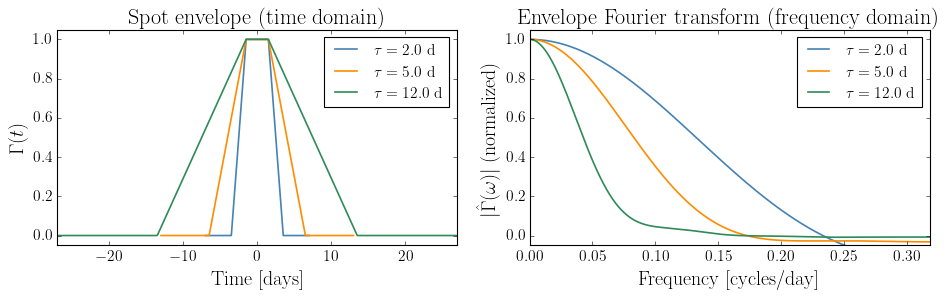

In [ ]:
lspot = 3.0
tau_vals = [2.0, 5.0, 12.0]
colors = ["steelblue", "darkorange", "seagreen"]

omega = np.linspace(0.0, 2.0, 1000)   # rad/day
freq  = omega / (2 * np.pi)            # cycles/day

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for tau, c in zip(tau_vals, colors):
    env = TrapezoidSymmetricEnvelope(lspot=lspot, tau_spot=tau)

    # Time domain
    t_max = 2 * tau + lspot
    t = np.linspace(-t_max, t_max, 800)
    axes[0].plot(t, env.Gamma(t), color=c, label=rf"$\tau={tau}$ d", lw=1.5)

    # Frequency domain
    Gh = np.array(env.Gamma_hat(omega))
    Gh /= Gh.max()           # normalize to peak = 1 for visual comparison
    axes[1].plot(freq, Gh, color=c, label=rf"$\tau={tau}$ d", lw=1.5)

axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel(r"$\Gamma(t)$")
axes[0].set_title("Spot envelope (time domain)")
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_xlim(-t_max, t_max)
axes[0].legend()

axes[1].set_xlabel("Frequency [cycles/day]")
axes[1].set_ylabel(r"$|\hat{\Gamma}(\omega)|$ (normalized)")
axes[1].set_title("Envelope Fourier transform (frequency domain)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlim(0, max(freq))
axes[1].legend()

plt.tight_layout()
plt.show()

Longer `tau_spot` compresses the spectral peak — a spot that lives for many rotation cycles produces a more coherent, narrower signal. Now we vary `lspot` at fixed `tau_spot` to see how the plateau duration adds sidelobes.

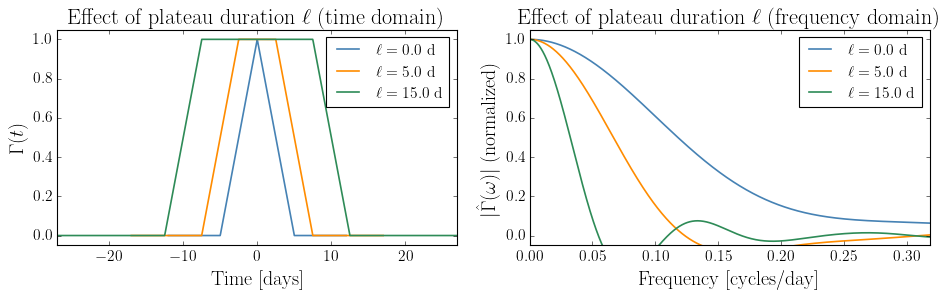

In [24]:
tau_spot = 5.0
lspot_vals = [0.0, 5.0, 15.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lspot, c in zip(lspot_vals, colors):
    env = TrapezoidSymmetricEnvelope(lspot=lspot, tau_spot=tau_spot)

    # Time domain
    t_max = 2 * tau_spot + lspot + 2
    t = np.linspace(-t_max, t_max, 1000)
    axes[0].plot(t, env.Gamma(t), color=c, label=rf"$\ell={lspot}$ d", lw=1.5)

    # Frequency domain
    Gh = np.array(env.Gamma_hat(omega))
    Gh /= Gh.max()
    axes[1].plot(freq, Gh, color=c, label=rf"$\ell={lspot}$ d", lw=1.5)

axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel(r"$\Gamma(t)$")
axes[0].set_title(r"Effect of plateau duration $\ell$ (time domain)")
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_xlim(-t_max, t_max)
axes[0].legend()

axes[1].set_xlabel("Frequency [cycles/day]")
axes[1].set_ylabel(r"$|\hat{\Gamma}(\omega)|$ (normalized)")
axes[1].set_title(r"Effect of plateau duration $\ell$ (frequency domain)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlim(0, max(freq))
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Rotation Harmonics $c_n^2$: inclination shapes the harmonic amplitudes

The visibility function $\Pi(t)$ describes how a spot's projected area changes as the star rotates. Expanded as a Fourier series in the rotation angle, its coefficients $c_n(\phi)$ determine **which harmonics of the rotation frequency** appear in the PSD — and with what amplitude.

Key properties:
- $c_0^2$: the DC component. A spot visible at all rotation phases (pole-on star or spot at pole) contributes a flat offset.
- $c_1^2$: the fundamental at $\omega_0 = 2\pi/P_{\rm eq}$. Dominant for equatorial spots on edge-on stars.
- $c_2^2, c_3^2, \ldots$: higher harmonics. Their amplitudes depend strongly on inclination.

Below we show $c_n^2$ for an equatorial spot ($\phi = 0$) at three inclinations. The harmonic spectrum determines which peaks appear in the full PSD.

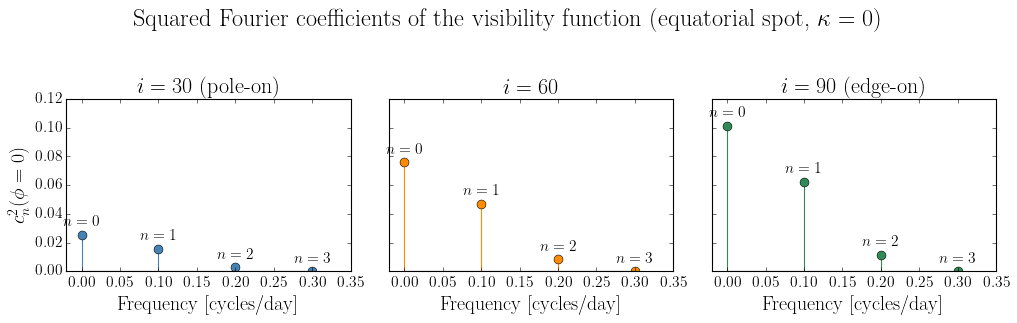

In [ ]:
peq = 10.0      # rotation period [days]
n_harmonics = 3
ns = np.arange(n_harmonics + 1)   

inc_vals = [np.pi / 6, np.pi / 3, np.pi / 2]
inc_labels = [r"$i = 30°$ (pole-on)", r"$i = 60°$", r"$i = 90°$ (edge-on)"]
phi_equator = 0.0

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, inc, label, c in zip(axes, inc_vals, inc_labels, colors):
    vis = VisibilityFunction(peq=peq, kappa=0.0, inc=inc)
    cn_sq = np.array(vis.cn_squared(phi=phi_equator, n_harmonics=n_harmonics))

    freq_harm = ns / peq   # harmonic frequencies [cycles/day]
    markerline, stemlines, baseline = ax.stem(
        freq_harm, cn_sq,
        linefmt=c, markerfmt="o", basefmt="k-"
    )
    markerline.set_color(c)
    markerline.set_markersize(8)

    for n, f, val in zip(ns, freq_harm, cn_sq):
        ax.annotate(
            rf"$n={n}$",
            xy=(f, val), xytext=(0, 8), textcoords="offset points",
            ha="center", fontsize=14
        )

    ax.set_title(label)
    ax.set_xlabel("Frequency [cycles/day]")
    ax.set_xlim(-0.02, (n_harmonics + 0.5) / peq)

axes[0].set_ylabel(r"$c_n^2(\phi=0)$")
fig.suptitle(r"Squared Fourier coefficients of the visibility function (equatorial spot, $\kappa=0$)", y=1.02)
plt.tight_layout()
plt.show()

At $i = 90°$ (edge-on), the spot disappears behind the star every half-rotation, producing a strong fundamental ($n=1$) and visible second harmonic ($n=2$). At $i = 30°$ (nearly pole-on), the spot never fully disappears, so $c_0^2$ dominates — the variation is mostly a slow modulation, not a periodic dip.

These coefficients weight the spectral peaks in the full PSD: only harmonics with large $c_n^2$ appear prominently.

## 3. Full Analytic PSD: combining envelope spectrum and rotation harmonics

When both components are active, the PSD is an **envelope spectrum convolved with a harmonic comb**: discrete peaks at $n\omega_0$ whose widths are set by $|\hat{\Gamma}(\omega)|^2$ and whose amplitudes are set by $c_n^2$.

The `AnalyticKernel.compute_psd(omega)` method evaluates this integral analytically over the latitude distribution. We compare it below against the median PSD estimated from an ensemble of simulated lightcurves — this validates that the analytic formula correctly predicts the frequency-domain behavior of the physical model.

### Model setup

In [27]:
envelope = TrapezoidSymmetricEnvelope(
    lspot=5.0,      # plateau duration [days]
    tau_spot=7.0,   # rise/decay timescale [days]
)

visibility = VisibilityFunction(
    peq=10.0,        # rotation period [days]
    kappa=0.0,       # solid-body rotation
    inc=np.pi / 2,   # edge-on inclination
)

model = SpotEvolutionModel(
    envelope=envelope,
    visibility=visibility,
    sigma_k=0.03,
)

kernel = AnalyticKernel(model, n_harmonics=3, n_lat=64)

### Analytic PSD

We evaluate `compute_psd` on a dense frequency grid. The result shows peaks at $f = n/P_{\rm eq}$ ($n = 1, 2, 3, \ldots$) broadened by the envelope spectrum.

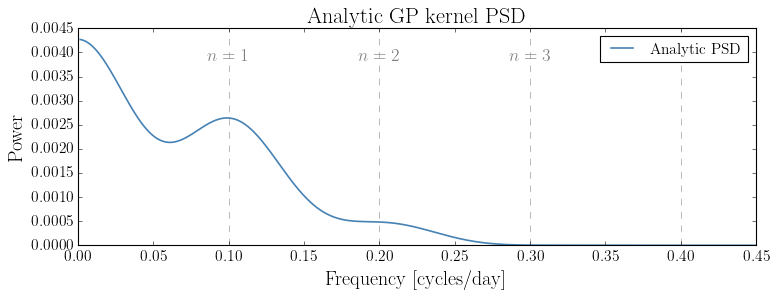

In [29]:
peq = model.peq
freq_max = 4.5 / peq   # show up to ~4th harmonic
n_freq = 2000
omega_grid = np.linspace(0.01, 2 * np.pi * freq_max, n_freq)

freq_analytic, psd_analytic = kernel.compute_psd(omega_grid)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freq_analytic, psd_analytic, color="steelblue", lw=1.5, label="Analytic PSD")

# Mark harmonic frequencies
for n in range(1, 5):
    f_n = n / peq
    if f_n <= freq_max:
        ax.axvline(f_n, color="gray", lw=0.8, ls="--", alpha=0.6)
        ax.text(f_n, ax.get_ylim()[1] * 0.85, rf"$n={n}$",
                ha="center", fontsize=16, color="gray")

ax.set_xlabel("Frequency [cycles/day]")
ax.set_ylabel("Power")
ax.set_title("Analytic GP kernel PSD")
ax.legend()
plt.tight_layout()
plt.show()

### Comparison with simulated lightcurves

We simulate an ensemble of lightcurves from the same physical model and compute their median Lomb-Scargle PSD. Both PSD curves are normalized to unit total power so their shapes can be compared directly.

In [30]:
# Simulate an ensemble of lightcurves
nsims  = 200
nspot  = 30
tsim   = 300    # days — long enough for good frequency resolution
tsamp  = 0.5    # cadence [days]

psd_list = []
for _ in range(nsims):
    lc = LightcurveModel.from_spot_model(model, nspot=nspot, tsim=tsim, tsamp=tsamp)
    flux = lc.flux
    freq_num, power_num = compute_psd(
        flux, t=lc.t,
        freq_min=0.5 / tsim,
        freq_max=freq_max,
        normalization="psd",
    )
    psd_list.append(power_num)

psd_median = np.median(np.stack(psd_list), axis=0)

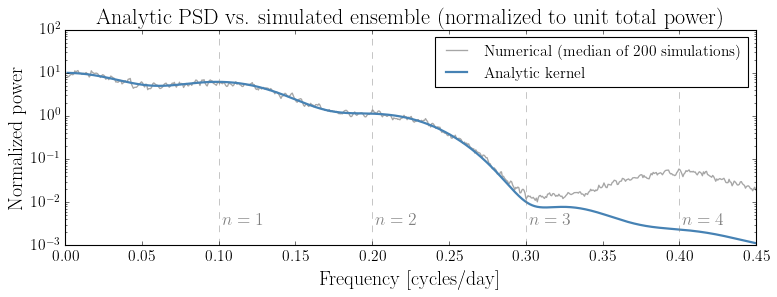

In [32]:
# Normalize both curves to unit total power for shape comparison
df_num     = freq_num[1] - freq_num[0]
df_analytic = freq_analytic[1] - freq_analytic[0]

mask = freq_analytic <= freq_max

psd_num_norm      = psd_median / (np.sum(psd_median) * df_num)
psd_analytic_norm = psd_analytic[mask] / (np.sum(psd_analytic[mask]) * df_analytic)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(freq_num, psd_num_norm, color="gray", alpha=0.7, lw=1.2,
            label=f"Numerical (median of {nsims} simulations)")
ax.semilogy(freq_analytic[mask], psd_analytic_norm, color="steelblue", lw=2,
            label="Analytic kernel")

for n in range(1, 5):
    f_n = n / peq
    if f_n <= freq_max:
        ax.axvline(f_n, color="gray", lw=0.8, ls="--", alpha=0.5)
        ax.text(f_n + 0.002, ax.get_ylim()[0] * 3, rf"$n={n}$",
                ha="left", fontsize=16, color="gray")

ax.set_xlabel("Frequency [cycles/day]")
ax.set_ylabel("Normalized power")
ax.set_title("Analytic PSD vs. simulated ensemble (normalized to unit total power)")
ax.legend()
plt.tight_layout()
plt.show()

The analytic kernel reproduces the harmonic peak positions and relative amplitudes of the simulated ensemble. Small residuals at high frequencies reflect finite-sample noise in the median PSD.

### Effect of spot lifetime on spectral peak width

Shorter-lived spots produce **broader** harmonic peaks. We demonstrate this by holding the rotation period fixed and varying `tau_spot`.

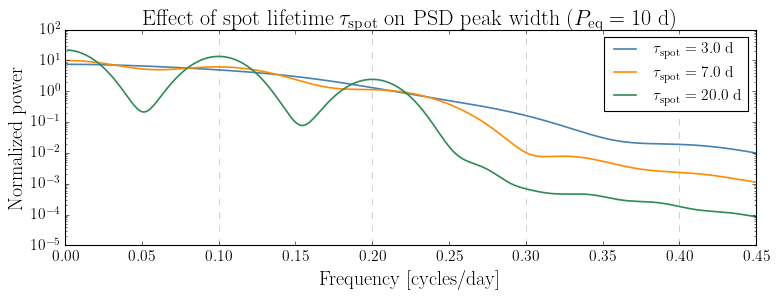

In [33]:
tau_vals_psd = [3.0, 7.0, 20.0]

fig, ax = plt.subplots(figsize=(10, 4))

for tau, c in zip(tau_vals_psd, colors):
    env_i = TrapezoidSymmetricEnvelope(lspot=5.0, tau_spot=tau)
    model_i = SpotEvolutionModel(envelope=env_i, visibility=visibility, sigma_k=0.03)
    kernel_i = AnalyticKernel(model_i, n_harmonics=3)
    freq_i, psd_i = kernel_i.compute_psd(omega_grid)

    psd_i_norm = psd_i / (np.trapezoid(psd_i, freq_i))
    ax.semilogy(freq_i, psd_i_norm, color=c, lw=1.5, label=rf"$\tau_{{\rm spot}}={tau}$ d")

for n in range(1, 5):
    f_n = n / peq
    if f_n <= freq_max:
        ax.axvline(f_n, color="gray", lw=0.8, ls="--", alpha=0.4)

ax.set_xlabel("Frequency [cycles/day]")
ax.set_ylabel("Normalized power")
ax.set_title(r"Effect of spot lifetime $\tau_{\rm spot}$ on PSD peak width ($P_{\rm eq}=10$ d)")
ax.legend()
plt.tight_layout()
plt.show()

Short-lived spots ($\tau_{\rm spot} = 3$ d) produce broad, featureless peaks because each spot coherently contributes for only a fraction of a rotation period. Long-lived spots ($\tau_{\rm spot} = 20$ d) produce sharp, well-resolved harmonic peaks because each spot rotates many times before decaying.

This spectral peak width is a direct observable: fitting the PSD constrains both the rotation period (peak position) and the spot lifetime (peak width) simultaneously.